<h1>Project 1: Image Compression using DCT and DFT</h1>
<p>In this project well implement two different image compression techniques which are Discrete Cosine Transform and Discrete Fourier Transform. We'll compare how each one perfoms and how this relates to their mathematics.</p>

<h3>first we start with image preprocessing</h3> 

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from scipy.fftpack import dct, idct, fft, ifft
from skimage.util import img_as_float
from skimage.color import rgb2gray
import cv2

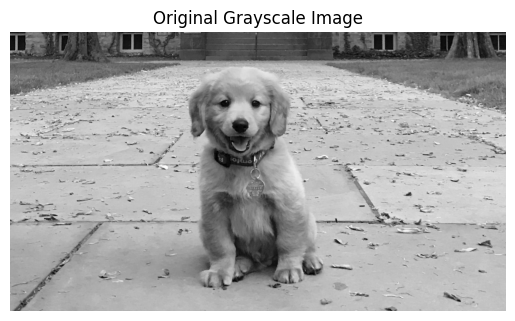

In [5]:
#image loading
image = cv2.imread('dog.jpg')
# image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
image = img_as_float(image)
gray_image = rgb2gray(image)
plt.imshow(gray_image, cmap='gray')
plt.title('Original Grayscale Image')
plt.axis('off')
plt.show()

In [ ]:
#i'll resize it to 256x256 for simplicity
image_resized = cv2.resize(gray_image,(256,256))

<h3> Now let's Divide the image into 8x8 blocks </h3>

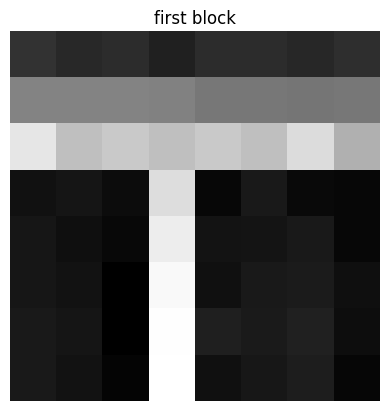

In [ ]:
blksize =8
blocks = []
for i in range(0, image_resized.shape[0], blksize):
    for j in range(0, image_resized.shape[1], blksize):
        block = image_resized[i:i+blksize, j:j+blksize]
        blocks.append(block)
blocks = np.array(blocks)
plt.imshow(blocks[0], cmap='gray')
plt.title('first block')
plt.axis('off')
plt.show()

### Next we apply DCT to each block...but let's first understannd what and how DCT works:
<p>Given a signal x[n], we could previously use DFT to transform it to frequency domain where x[f] = summation of X[m] * e^(-j2pikn/N) over k=0 to N-1 and to get back to time representaion -> IDFT is then x[n] = summation of X[k]/N * e^(j2pikn/N) over k=0 to N-1. Obviously this yeilds complex numbers/sinusiods which are not ideal, nor cost effective, for image processing. It won't matter a lot when working on LTI systems, but for compression tasks, we want to avoid complex numbers as much as possible. Loss of information happens when we quantize the coefficients, and working with complex numbers makes this loss worse.
On the other hand, with DCT, the signal is represented as a sum of cosine functions oscillating at different frequencies, so losing a part of signal is less effective as another half represents the same information.
DCT is a similar transform that uses yields real numbers and cosines instead of complex exponentials. In DCT, large amount of signal information is cocentrated mostly in lower frequencies, which makes it more suitable for compression tasks as we can lose parts of the higher frequency components with less quality loss.(As we learned in information thery, higher freqs represent less important and the more probability of occurance, the less information they carry).</p>

In [8]:
#number of blocks
blocks

array([[[0.11942357, 0.09649159, 0.10940963, ..., 0.10660188,
         0.09439648, 0.1115875 ],
        [0.29624239, 0.29817254, 0.29720069, ..., 0.27003222,
         0.26441973, 0.26829052],
        [0.51119687, 0.42570362, 0.44732324, ..., 0.4247845 ,
         0.48798648, 0.39222103],
        ...,
        [0.05738051, 0.04939951, 0.01028154, ..., 0.064856  ,
         0.06946382, 0.04220961],
        [0.06392157, 0.05667586, 0.00945208, ..., 0.06791973,
         0.08321206, 0.03949338],
        [0.06500375, 0.04917961, 0.01878346, ..., 0.06152274,
         0.07329892, 0.02331955]],

       [[0.45264738, 0.50246078, 0.44372917, ..., 0.48709225,
         0.48905304, 0.45953032],
        [0.45253074, 0.48562561, 0.51996998, ..., 0.49050831,
         0.49219336, 0.44394178],
        [0.42572046, 0.4449087 , 0.46205025, ..., 0.48566762,
         0.45705243, 0.47325294],
        ...,
        [0.44957078, 0.42269275, 0.43897645, ..., 0.49956468,
         0.50046848, 0.47672461],
        [0.5

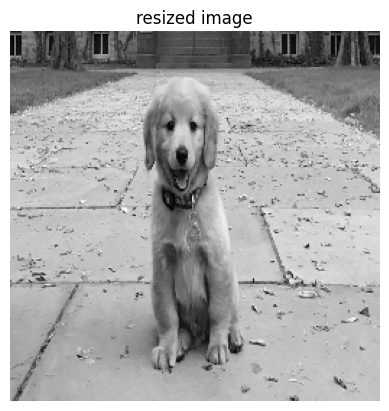

In [17]:
#plot resized image
plt.imshow(image_resized, cmap='gray')
plt.title('resized image')
plt.axis('off')
plt.show()

In [ ]:
#apply dct 2d with 1d function
blocks.shape[0]

1024

In [ ]:
dct_rows = np.zeros_like(blocks)
dct_blocks = np.zeros_like(blocks)
for r in range (blocks.shape[0]):
    dct_rows[r] = dct(blocks[r], axis=1, norm='ortho')
for c in range (blocks.shape[0]):
    dct_blocks[c]=dct(dct_rows[c], axis=0, norm='ortho')


Now let's compute energy compaction for DCT 8x8 blocks:

In [ ]:
dct_blocks

In [ ]:
squaresum = []
for i in range(dct_blocks.shape[0]):
    squaresum.append(np.sum(np.power(dct_blocks[i], 2)))
squaresum = np.array(squaresum)
sorted_squaresum = (np.sort(squaresum))[::-1]
# for i in range(len(sorted_squaresum)):

